# Chapter 9 Solutions: Quantum Fourier Transform

---

**📘 INSTRUCTOR NOTE:**
- Solutions use the same utilities as the main textbook notebooks
- Students should work through the main chapter notebook first
- Some solutions may still be in development (marked as WIP)

---


In [6]:
# Solutions Setup
import numpy as np
import matplotlib.pyplot as plt
# Add utilities to path
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from Chapter05_QuantumGates_functions import simulateCircuit #type: ignore
from Chapter09_QFT_functions import trignometricSignal,createDFTMatrix, processDFTResult, createQFTMatrix, processQFTResult, plotDFTResult #type: ignore

print('Solutions setup complete!')

Solutions setup complete!


### DFT Exercise

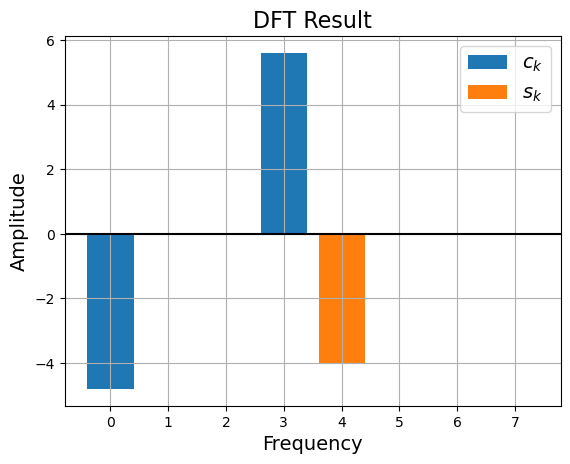

In [7]:
def exerciseSignal(t):
	s = -0.3 + 0.35*np.cos(3*2*np.pi*t) - 0.25*np.sin(4*2*np.pi*t)
	return s

M = 16 # We set the number of discrete samples here
t = np.linspace(0,1,M,endpoint = False) # need to eliminate the last point
y = exerciseSignal(t)

DFTMatrix = createDFTMatrix(M)# type: ignore
phi = np.matmul(DFTMatrix,y)

[c,s] = processDFTResult(phi)# type: ignore

plotDFTResult(c,s,M)# type: ignore

### DFT Leaky Signal

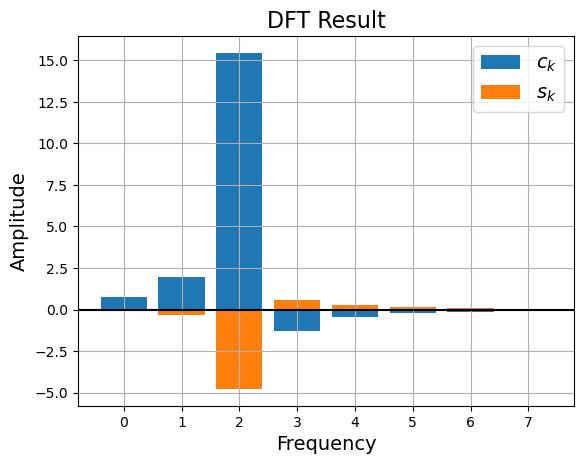

In [8]:
def leakySignal(t):
	s = np.cos(2.1*2*np.pi*t) 
	return s


M = 16 # We set the number of discrete samples here
t = np.linspace(0,1,M,endpoint = False) # need to eliminate the last point
y = leakySignal(t)

DFTMatrix = createDFTMatrix(M)# type: ignore
phi = np.matmul(DFTMatrix,y)

[c,s] = processDFTResult(phi)# type: ignore

plotDFTResult(c,s,M)# type: ignore

### Recreate signal from leaky data

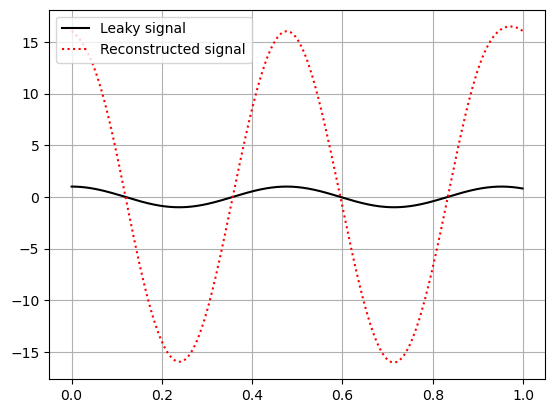

In [9]:

nContinuousSamples = 1000 # for plotting
tPlot = np.linspace(0,1,nContinuousSamples,endpoint = False)
plt.plot(tPlot,leakySignal(tPlot),'black')
yReconstructed = trignometricSignal(tPlot,c,s)# type: ignore
plt.plot(tPlot, yReconstructed, 'r:')
plt.legend(['Leaky signal', 'Reconstructed signal'])
plt.grid(True)

### DFT Signal Reconstruction

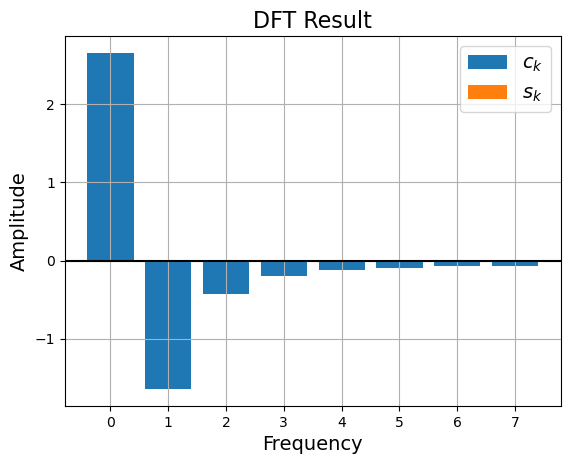

Error: 3.78125


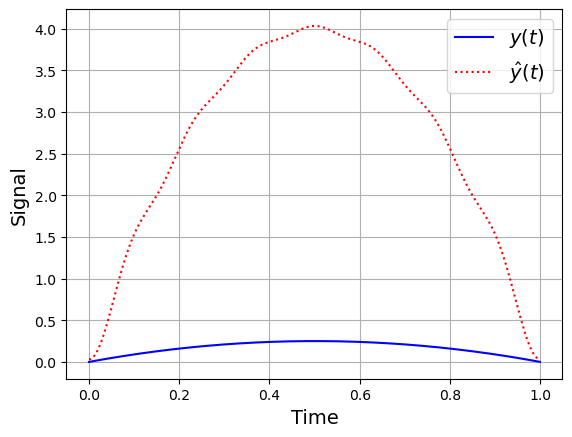

In [10]:
M = 16
t = np.linspace(0,1,M,endpoint = False) 
y = t*(1-t)
	
DFTMatrix = createDFTMatrix(M)# type: ignore
phi = np.matmul(DFTMatrix,y)
[c,s] = processDFTResult(phi)# type: ignore

plotDFTResult(c,s,M)# type: ignore

S = 1000
tPlot = np.linspace(0,1,S,endpoint = False) 
yPlot = tPlot*(1-tPlot)
yDFT = trignometricSignal(tPlot,c,s)# type: ignore

e = np.max(np.abs(yPlot-yDFT))
print("Error:", e)
plt.figure()
plt.xlabel('Time', fontsize=14)
plt.ylabel('Signal', fontsize=14)
plt.grid(visible=True)
plt.plot(tPlot,yPlot,'blue',label =r"$y(t)$")
plt.plot(tPlot,yDFT,'r:',label =r"$\hat y(t)$")
plt.legend( fontsize=14)



### Error vs M

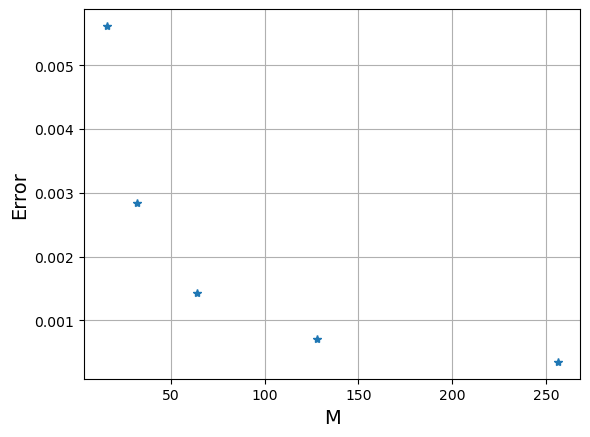

In [11]:
Errors = [0.005617,0.002836,0.00143237,0.000710962,0.0003495869]
MValues = [16,32,64,128,256]

plt.figure()
plt.xlabel('M', fontsize=14)
plt.ylabel('Error', fontsize=14)
plt.grid(visible=True)
plt.plot(MValues,Errors,'*')

## FFT

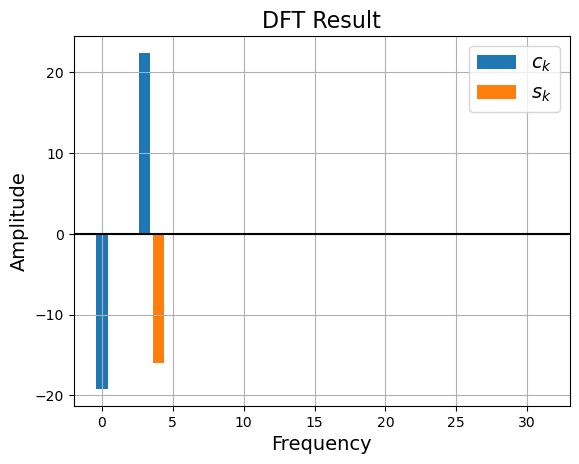

In [12]:
from numpy.fft import fft
M = 64 # We set the number of discrete samples here
t = np.linspace(0,1,M,endpoint = False) # need to eliminate the last point
y = exerciseSignal(t)

phiFFT = fft(y)
[c,s] = processDFTResult(phiFFT)# type: ignore
plotDFTResult(c,s,M)# type: ignore